In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
# outlier detection and removal using Z- score method 

In [3]:
pd.read_csv('placement.csv')

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [4]:
df=pd.read_csv('placement.csv')

In [5]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


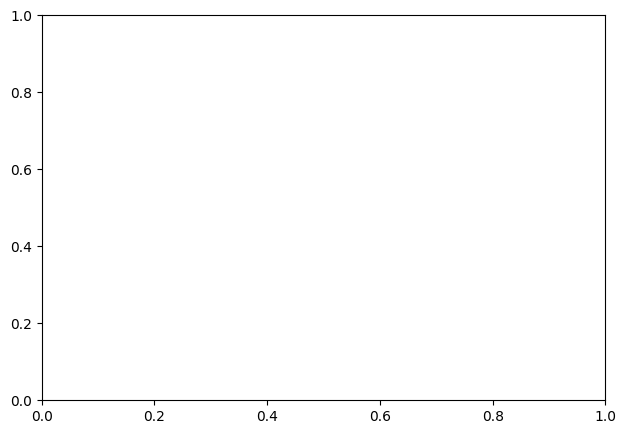

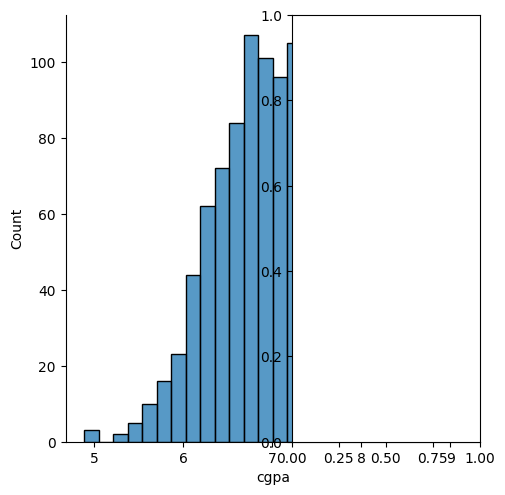

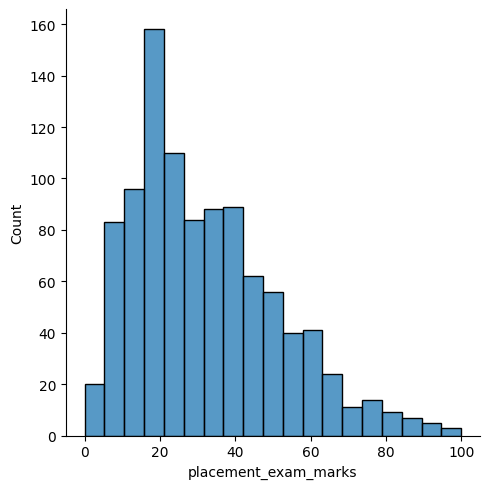

In [6]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.displot(df['cgpa'])

plt.subplot(1,2,2)
sns.displot(df['placement_exam_marks'])
plt.show()

In [10]:
#df['cgpa'].discribe()

In [7]:
upper_limit=df['cgpa'].mean()+df['cgpa'].std()
upper_limit

7.57713787513239

In [8]:
lower_limit=df['cgpa'].mean()+df['cgpa'].std()
lower_limit

7.57713787513239

In [14]:
# finding outlier 
df[(df['cgpa']>8.80) | (df['cgpa']<5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [16]:
# Trimming 
new_df = df[(df['cgpa']<8.80) &(df['cgpa']>5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [17]:
new_df.shape

(995, 3)

In [18]:
new_df.size

2985

In [33]:
# calculate the zscore 
# zscore formula ====(new value= (x-U)/a)
df['cgpa_zscore'] = (df['cgpa']-df['cgpa'].mean())/df['cgpa'].std()
df['cgpa_zscore']

0      0.371425
1      0.809810
2      0.939701
3     -0.878782
4      0.436371
         ...   
995    3.099150
996    3.505062
997   -3.362960
998    2.693239
999   -3.346724
Name: cgpa_zscore, Length: 1000, dtype: float64

In [34]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [35]:
df['cgpa_zscore'].describe()

count    1.000000e+03
mean    -1.465494e-16
std      1.000000e+00
min     -3.362960e+00
25%     -6.677081e-01
50%     -2.013321e-03
75%      6.636815e-01
max      3.505062e+00
Name: cgpa_zscore, dtype: float64

In [36]:
df[df['cgpa_zscore']>3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [37]:
df[df['cgpa_zscore']<3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363
997,4.89,34.0,0,-3.362960
998,8.62,46.0,1,2.693239


In [40]:
# Trimming 
new_df = df[(df['cgpa_zscore']<3) &(df['cgpa_zscore']>-3)]
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


In [41]:
# capping 
lower_limit

7.57713787513239

In [42]:
upper_limit 

7.57713787513239

In [44]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']>lower_limit,
        lower_limit,
        df['cgpa']
    )
)
df.shape

(1000, 4)

In [45]:
df['cgpa'].describe()

count    1000.000000
mean        6.910208
std         0.534136
min         4.890000
25%         6.550000
50%         6.960000
75%         7.370000
max         7.577138
Name: cgpa, dtype: float64